In [1]:
import ast
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

label = 'pident_90'
os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()
title_ifont = FontProperties(fname=ifont_path, size=8)

plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

def get_base_data(genus_name, label):
    base_folder = f'/active-data/analysis_results/chr_pla/genus'
    folder = f'{base_folder}/statistics_records/{genus_name}'
    figure_fold = f'{base_folder}/figures'
    os.makedirs(figure_fold, exist_ok=True)
    os.chdir(folder)

    fraction_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
    df = fraction_data.rename(columns={
        f'average plasmid fraction-{label}': 'plasmidness',
        'size': 'size'
    })

    prediction_re = pd.read_csv("./annotations/NMS_replicon_type_prediction_results.csv")
    prediction_re = prediction_re[prediction_re[f'category-{label}'].isin(['typical plasmid', 'intermediate replicon'])]
    return base_folder, folder, figure_fold, df, prediction_re, fraction_data

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
def get_heatmap_data(prediction_re, label):
    df_rename = prediction_re.copy()
    cols = ['initial_type','plasflow_pdc','plasmer_pdc','rfplasmid_pdc','deeplasmid_pdc']
    df_sort = df_rename.sort_values(f'average plasmid fraction-{label}', ascending=True).reset_index(drop=True)
    score = df_sort[f'average plasmid fraction-{label}'].values
    score500 = score[:500]
    threshold = 0.3
    th_idx = (score >= threshold).argmax()
    df_num = df_sort[cols].map(lambda x:1 if x=='plasmid' else 2 if x=='chromosome' else 0).T
    df_num500 = df_num.iloc[:,:500]
    return cols, score, score500, th_idx, df_num, df_num500

def plot_heatmap(ax, data, title, cols, th_idx):
    n_tools, n_seqs = data.shape
    c_base, c_chr, c_unc, lc = '#cce7ff', '#ff962d', '#b0b0b0', 'red'
    ax.add_patch(Rectangle((0,0),n_seqs,n_tools,facecolor=c_base,zorder=1))
    for i in range(n_tools):
        for j in range(n_seqs):
            v = data.iloc[i,j]
            if v==2: 
                ax.add_patch(Rectangle((j,i),1,1,facecolor=c_chr,zorder=2))
            elif v==0: 
                ax.add_patch(Rectangle((j,i),1,1,facecolor=c_unc,zorder=2))
    ax.axvline(th_idx, c=lc, ls='--', lw=0.5, zorder=5)
    ax.text(th_idx, -0.15, 'Plasmidness=0.3', ha='center', fontsize=7, c=lc)
    ax.set_xlim(0,n_seqs)
    ax.set_ylim(0,n_tools)
    ax.invert_yaxis()
    ax.set_yticks(np.arange(n_tools)+0.5)
    display_names = ['Initial_type','PlasFlow','Plasmer','RFPlasmid','Deeplasmid']
    ax.set_yticklabels(display_names)
    ax.set_xticks([])
    ax.set_title(title, pad=7, fontproperties=title_ifont)

def plot_label_band(ax, th_idx, total, color_t, color_p):
    ax.add_patch(Rectangle((0, 0), min(th_idx, total), 1, facecolor=color_t))
    ax.add_patch(Rectangle((min(th_idx, total), 0), total-min(th_idx, total), 1, facecolor=color_p))
    ax.set_xlim(0, total)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)

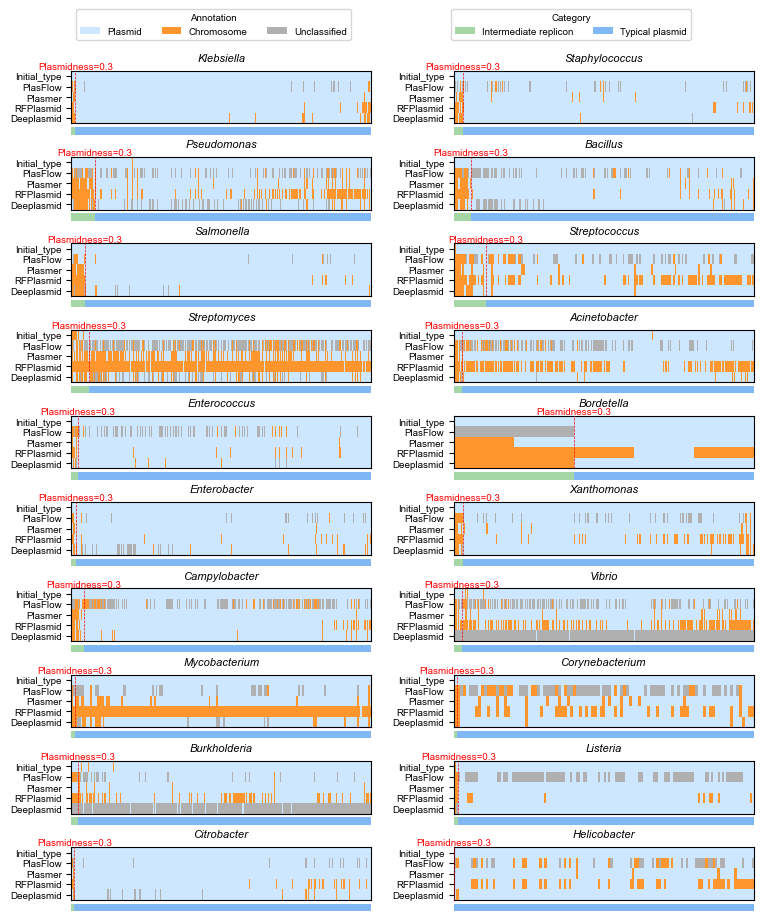

In [3]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(7.5, 7.5))

label = 'pident_90'

c_base, c_chr, c_unc = '#cce7ff', '#ff962d', '#b0b0b0',
annotation_elements = [Patch(facecolor=c_base,label='Plasmid'), Patch(facecolor=c_chr,label='Chromosome'), Patch(facecolor=c_unc,label='Unclassified')]
fig.legend(handles=annotation_elements, loc='lower left',bbox_to_anchor=(0.08,0.99),fontsize=7,title='Annotation',ncol=3)

cate_elements = [Patch(facecolor='#a5d6a5',label='Intermediate replicon'), Patch(facecolor='#7fb8f5',label='Typical plasmid')]
fig.legend(handles=cate_elements, loc='lower left',bbox_to_anchor=(0.58,0.99),fontsize=7,title='Category',ncol=2)

for i, genus_name in enumerate(keep_genus):
    if genus_name == 'Escherichia':
        continue
    base_folder, folder, figure_fold, df, prediction_re, fraction_data = get_base_data(genus_name, label)
    ax_heatmap = fig.add_axes([0.08+0.51*((i+1)%2), 1-0.115*int((i+1)/2), 0.4, 0.07])
    label_band_height = 0.01
    label_space = 0.005
    ax_label = fig.add_axes([ax_heatmap.get_position().x0, ax_heatmap.get_position().y0 - label_band_height - label_space, ax_heatmap.get_position().width, label_band_height])
    cols, score, score500, th_idx, h_data, h500_data = get_heatmap_data(prediction_re, label)
    plot_heatmap(ax_heatmap, h_data, genus_name, cols, th_idx)
    plot_label_band(ax_label, th_idx, len(score), '#a5d6a5', '#7fb8f5')

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_all_genera_replicon_annotation_result.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_all_genera_replicon_annotation_result.png", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()